<p><left> <img src="docs/images/header.png" width="1000"/> </p></left>

# LISFLOOD - a distributed hydrological rainfall-runoff model

<br>
<br>
<br>

LISFLOOD is a spatially distributed, semi-physical hydrological rainfall-runoff model that has been developed by the Joint Research Centre (JRC) of the European Coimission in late 90s. Since then, LISFLOOD has been applied to a wide range of applications such as all kind of water resourses assessments looking at e.g. the effects of climate and land-use change as well as river regulation measures. Its most prominent applications are probably the [European Flood Awareness System](https://european-flood.emergency.copernicus.eu/en) (EFAS)  and the [Global Flood Awareness System](https://global-flood.emergency.copernicus.eu/), both operated under [Copernicus Emergency Management Service](https://emergency.copernicus.eu/) (CEMS).

Its wide applicability is due to its modular structure as well as its temporal and spatial flexibility. The model can be extended with additional modules when need arises, to satisfy the new target objective. In that sense it can be extended to include anything from a better representation of a particular hydrological flow to the implementation of anthropogenic-influenced processes. At the same time the model has been designed to be applied across a wide range of spatial and temporal scales. LISFLOOD is grid-based, and applications so far have employed grid cells of as little as 100 metres for medium-sized catchments, to 5000 metres for modelling the whole of Europe and up to 0.1° (around 10 km) for modelling globally. Long-term water balance can be simulated (using a daily time step), as well as individual flood events (using hourly time intervals, or even smaller).

Although LISFLOOD’s primary output product is channel discharge, all internal rate and state variables (soil moisture, for example) can be written as output as well. All output can be written as grids, or time series at user-defined points or areas. The user has complete control over how output is written, thus minimising any waste of disk space or CPU time.

Go to [Lisflood OS page](https://ec-jrc.github.io/lisflood/) for more information. Other useful resources:

| **Project** | **Documentation** | **Source code** |
| :--- | :--- | :--- |
| Lisflood | [Docs](https://ec-jrc.github.io/lisflood-model/) <br> [User guide](https://ec-jrc.github.io/lisflood-code/) | https://github.com/ec-jrc/lisflood-code |
| Lisvap | [Docs](https://ec-jrc.github.io/lisflood-lisvap/) | https://github.com/ec-jrc/lisflood-lisvap |
| Calibration tool | [Docs](https://ec-jrc.github.io/lisflood-calibration/) | https://github.com/ec-jrc/lisflood-calibration |
| Lisflood Utilities | | https://github.com/ec-jrc/lisflood-utilities |
| Lisflood Usecases | | https://github.com/ec-jrc/lisflood-usecases |


## Initialization

This section loads relevant Python modules for the following analysis.

In [1]:
import functools
import ipywidgets
import os
from ipyfilechooser import FileChooser

from matplotlib import rc

from lisflood_ui import show_settings, plot_results

%matplotlib ipympl

rc('animation', html='jshtml')

## Run the model

The following cell allows you to run a LISFLOOD use case. You will be asked to provide the LISFLOOD settings file for the pre-run (or initialization run) and the main run. You have three use cases to choose from, the Fraser river (folder `LF_fraser_usecase`), the Po river (folder `LF_ETRS89_UseCase`) or the Mekong river (folder `LF_mekong_usecase`). In each of those folders, you will find a template of the XML settings file for both the pre-run and the run.

Once you have selected your use case, you will be presented a set of tabs to configure your simulation.

* The tab `Optional modules` allows you to specify the hydrological modules in LISFLOOD that you want to activate in your runs.
* The tab `Simulation period` specifies the time frames for the pre-run and run, and the time step.
* The tab `Model parameters` presents the 14 parameters that are usually calibrated in LISFLOOD. You are given some default values, but you can play with the sliders to change the values of the parameters.
* The tab `Outputs` allows you to select the results that you want to save. They will be saved in a subfolder named `results` within the use case folder.

When you click on `Start`, the configuration you have set up in the tabs will be writen on the two settings files (pre-run and run), and the two LISFLOOD simulations will be executed sequentially.

In [2]:
# Create and configure file choosers for XML settings files
files_chosen = [FileChooser(os.getcwd()) for _ in range(2)]
files_chosen[0].title = '<b>Select the settings file for the PRE-RUN:</b>'
files_chosen[1].title = '<b>Select the settings file for the RUN:</b>'

for chooser in files_chosen:
    chooser.filter_pattern = '*.xml'
    chooser.use_dir_icons = True
    chooser.register_callback(functools.partial(show_settings, files_chosen=files_chosen))

# Explicitly display the file choosers in a vertical box
display(ipywidgets.VBox([files_chosen[0], files_chosen[1]]))

Button(description='Start', style=ButtonStyle())

## Explore the results

Please run the code cell below to visualize the outputs. The notebook can also be used to visualize data of previous LISFLOOD runs. When running the [Outputs](#Outputs) code cell, the notebook checks whether the [Processing](#Processing) code cell has been executed before. If yes, it opens the output files coming from this LISFLOOD run. If not, it opens another file chooser where you can choose the output folder that you would like to visualize. 

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import altair as alt
import xarray as xr
import cartopy.io.img_tiles as cimgt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt


from docs.lisflood_read_plot import read_tss
from lisflood_ui import update_variable, update_time

In [ ]:
```Python
def plot_results(
        chooser, 
        output_dir: Optional[Union[str, Path]] = None
):
    """
    Plot results of the LISFLOOD simulation.

    Args:
        chooser (_type_): _description_
        output_dir (_type_): _description_
    """
    # sets path to output directory depending on function parameters
    if output_dir:
        path_results = Path(chooser.selected_path)
        settings_file = next(path_results.parent.glob('*Run.xml'))
    else:
        path_model = Path(chooser.selected_path)
        path_results = path_model / 'results'
        settings_file = path_model / chooser.selected_filename

    # checks whether output data exists
    if not (any(path_results.glob('*.nc')) and any(path_results.glob('*.tss'))):
        print(f'No output files in {path_results}.')
        return

    global datevar

    # discharge time series
    tss_file = path_results / 'dis_run.tss'
    if tss_file.is_file():
        # read
        df = read_tss(
            tss=tss_file, 
            xml=settings_file,
            squeeze=False
        )
        df.columns = ['value']
        df.index.name = 'date'
        df.reset_index(inplace=True)
        df['setting'] = 'discharge'

        # plot
        selection = alt.selection_point(fields=['setting'], bind='legend')
        chart = alt.Chart(df
                ).mark_line(point=True
                ).encode(x='date:T',
                        y='value:Q',
                        color=alt.Color('setting', legend=alt.Legend(title="Variable")),
                        opacity=alt.condition(selection, alt.value(1), alt.value(0.2))
                ).add_params(selection
                ).interactive(bind_y=False
                ).properties(width=800, height=300)
        # display outputs
        display(ipywidgets.HTML(value = f"<left><b><font size=5>{'Discharge Time Series'}</b></left>"))
        display(chart)

    # output maps
    nc_files = nc_files = [file for file in path_results.glob('*.nc') if file.stem not in ['lzavin', 'avgdis']]
    if len(nc_files) == 0:
        print(f'No NetCDF files in the results folder: {path_results}.')
        return

    global datasets
    global date_slider
    global variable_dropdown
    global im
    global cbar 

    if 'datasets' in locals():
        datasets.clear()
    else:
        datasets = []

    # read maps
    datasets = {file.stem: xr.open_dataarray(file) for file in nc_files}

    # get dates from the datasets
    first_key = next(iter(datasets))
    datevar = datasets[first_key]['time'].data

    # create drowdown menu with all available outputs
    variable_dropdown = ipywidgets.Dropdown(
        options=list(datasets), 
        description='Variable:'
    )
    # create date slider for given time period
    date_slider = ipywidgets.IntSlider(
        min=0, 
        max=len(datevar) - 1, 
        step=1, 
        value=0,
        description='Date:'
    )
    # create simulation controls
    play = ipywidgets.Play(
        min=0,
        max=len(datevar) - 1,
        step=1,
        description="Press play",
        disabled=False
    )

    # plot the map
    out_spatial = ipywidgets.Output()
    with out_spatial:
        # extract data array
        variable = variable_dropdown.value
        da = datasets[variable]

        # Create a figure and axes with a Plate Carree projection.
        fig, ax = plt.subplots(
            figsize=(10, 8),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )

        # Set the extent of the map based on the data's geographical bounds.
        buffer = 0.5
        extent = [
                da.lon.min().item() - buffer,
                da.lon.max().item() + buffer,
                da.lat.min().item() - buffer,
                da.lat.max().item() + buffer
        ]
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Add the map image tiles for geographical context.
        request = cimgt.OSM()
        ax.add_image(request, 6)
    
        # Add geographical features to provide more context.
        ax.coastlines(resolution='50m', color='black', linewidth=1)
        ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)

        # Plot the data.
        im = ax.pcolormesh(
            da.lon,
            da.lat,
            da.isel(time=0).data,
            vmin=da.min().item(),
            vmax=da.max().item(),
            cmap=plt.cm.viridis_r,
            alpha=0.6,
            transform=ccrs.PlateCarree(),
        )

        update_time(0)

    # update variable, time or when a simulation is started
    ipywidgets.interactive(update_variable, variable=variable_dropdown)
    ipywidgets.interactive(update_time, date=date_slider)
    ipywidgets.jslink((play, 'value'), (date_slider, 'value'))

    # display outputs
    display(ipywidgets.HTML(value = f"<left><b><font size=5>{'Spatial Outputs'}</b></left>"))
    display(out_spatial)
    display(ipywidgets.HBox([play, date_slider, variable_dropdown]))
```

In [ ]:
# from typing import Optional, Union

# def plot_results2(
#         chooser, 
#         output_dir: Optional[Union[str, Path]] = None
# ):
#     """
#     Plot results of the LISFLOOD simulation.

#     Args:
#         chooser (_type_): _description_
#         output_dir (_type_): _description_
#     """
#     # sets path to output directory depending on function parameters
#     if output_dir:
#         path_results = Path(chooser.selected_path)
#         settings_file = next(path_results.parent.glob('*Run.xml'))
#     else:
#         path_model = Path(chooser.selected_path)
#         path_results = path_model / 'results'
#         settings_file = path_model / chooser.selected_filename

#     # checks whether output data exists
#     if not (any(path_results.glob('*.nc')) and any(path_results.glob('*.tss'))):
#         print(f'No output files in {path_results}.')
#         return

#     global datevar

#     # discharge time series
#     tss_file = path_results / 'dis_run.tss'
#     if tss_file.is_file():
#         # read
#         df = read_tss(
#             tss=tss_file, 
#             xml=settings_file,
#             squeeze=False
#         )
#         df.columns = ['value']
#         df.index.name = 'date'
#         df.reset_index(inplace=True)
#         df['setting'] = 'discharge'

#         # plot
#         selection = alt.selection_point(fields=['setting'], bind='legend')
#         chart = alt.Chart(df
#                 ).mark_line(point=True
#                 ).encode(x='date:T',
#                         y='value:Q',
#                         color=alt.Color('setting', legend=alt.Legend(title="Variable")),
#                         opacity=alt.condition(selection, alt.value(1), alt.value(0.2))
#                 ).add_params(selection
#                 ).interactive(bind_y=False
#                 ).properties(width=800, height=300)
#         # display outputs
#         display(ipywidgets.HTML(value = f"<left><b><font size=5>{'Discharge Time Series'}</b></left>"))
#         display(chart)

#     # output maps
#     nc_files = nc_files = [file for file in path_results.glob('*.nc') if file.stem not in ['lzavin', 'avgdis']]
#     if len(nc_files) == 0:
#         print(f'No NetCDF files in the results folder: {path_results}.')
#         return

#     global datasets
#     global date_slider
#     global variable_dropdown
#     global im
#     global cbar 

#     if 'datasets' in locals():
#         datasets.clear()
#     else:
#         datasets = []

#     # read maps
#     datasets = {file.stem: xr.open_dataarray(file) for file in nc_files}

#     # get dates from the datasets
#     first_key = next(iter(datasets))
#     datevar = datasets[first_key]['time'].data

#     # create drowdown menu with all available outputs
#     variable_dropdown = ipywidgets.Dropdown(
#         options=list(datasets), 
#         description='Variable:'
#     )
#     # create date slider for given time period
#     date_slider = ipywidgets.IntSlider(
#         min=0, 
#         max=len(datevar) - 1, 
#         step=1, 
#         value=0,
#         description='Date:'
#     )
#     # create simulation controls
#     play = ipywidgets.Play(
#     min=0,
#     max=len(datevar) - 1,
#     step=1,
#     description="Press play",
#     disabled=False
#     )

#     # plot map
#     out_spatial = ipywidgets.Output()
#     with out_spatial:
#         variable = variable_dropdown.value
#         da = datasets[variable]
#         plot_map(da)
#         update_time(0)

#     # update variable, time or when a simulation is started
#     ipywidgets.interactive(update_variable, variable=variable_dropdown)
#     ipywidgets.interactive(update_time, date=date_slider)
#     ipywidgets.jslink((play, 'value'), (date_slider, 'value'))

#     # display outputs
#     display(ipywidgets.HTML(value = f"<left><b><font size=5>{'Spatial Outputs'}</b></left>"))
#     display(out_spatial)
#     display(ipywidgets.HBox([play, date_slider, variable_dropdown]))

In [ ]:


# def update_time(date):
#     """
#     Callback function to update the map based on the selected date.   
#     """
#     global datasets
#     global datevar
#     global im
#     global variable_dropdown
    
#     variable = variable_dropdown.value
#     im.set_array(datasets[variable].isel(time=date).data.ravel())
#     plt.title(
#         f'{variable}: {pd.to_datetime(datevar[date]).strftime("%d %b %Y")}',
#         size='xx-large'
#         )
#     plt.draw()

# def update_variable(variable):
#     """
#     Callback function to update the map based on the selected variable.
#     """
#     global datasets
#     global datevar
#     global im
#     global cbar
#     global date_slider
    
#     im.set_array(datasets[variable].isel(time=date_slider.value).data.ravel())
#     im.autoscale()
#     cbar.update_normal(im)
#     title = '{}: {}'.format(parameter, datevar[0][date_slider.value].strftime('%d %b %Y'))
#     plt.title(title, size='xx-large')
#     plt.draw()

In [ ]:
# from typing import Optional

# def plot_map(da, title: Optional[str] = None):
#     """
#     Plots a geographical map with a data overlay.

#     This function encapsulates all the plotting logic for a single map,
#     making it modular and reusable. It's designed to be called from
#     your main program to create a clean, aesthetically pleasing plot.

#     Args:
#         da (MockDataArray or xarray.DataArray): The data to be plotted.
#         title (str): The title for the plot.
#     """
#     # Create a figure and axes with a Plate Carree projection.
#     fig, ax = plt.subplots(
#         figsize=(10, 8),
#         subplot_kw={'projection': ccrs.PlateCarree()}
#     )

#     # Set the extent of the map based on the data's geographical bounds.
#     buffer = 0.5
#     extent = [
#             da.lon.min().item() - buffer,
#             da.lon.max().item() + buffer,
#             da.lat.min().item() - buffer,
#             da.lat.max().item() + buffer
#     ]
#     ax.set_extent(extent, crs=ccrs.PlateCarree())

#     # Add the map image tiles for geographical context.
#     request = cimgt.OSM()
#     ax.add_image(request, 6)
    
#     # Add geographical features to provide more context.
#     ax.coastlines(resolution='50m', color='black', linewidth=1)
#     ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)

#     # Plot the data using pcolormesh.
#     im = ax.pcolormesh(
#         da.lon,
#         da.lat,
#         da.isel(time=0).data,
#         vmin=da.min().item(),
#         vmax=da.max().item(),
#         cmap=plt.cm.viridis_r,
#         alpha=0.6,
#         transform=ccrs.PlateCarree(),
#     )

#     # Add the color bar and set its label and font size.
#     cbar = plt.colorbar(im, shrink=0.5, pad=0.1)
#     cbar.set_label(da.attrs["units"], fontsize=12)
#     cbar.ax.tick_params(labelsize=12)

#     # Set the title of the plot.
#     if title:
#         ax.set_title(title, size='xx-large')

#     plt.show()

HTML(value='<left><b><font size=5>Discharge Time Series</b></left>')

alt.Chart(...)

HTML(value='<left><b><font size=5>Spatial Outputs</b></left>')

Output()

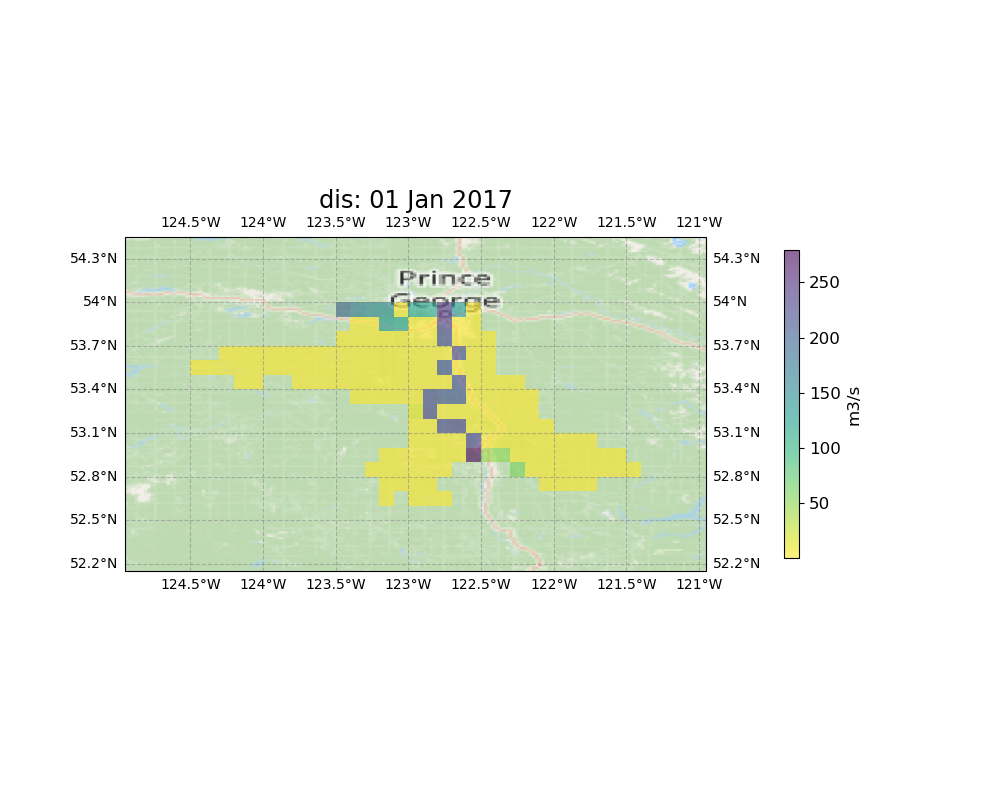

In [ ]:
# check if filechooser exist from processing
if 'files_chosen' in locals():
    plot_results(files_chosen[1], output_dir=False)
# if not show file chooser
else:
    # create file chooser for output folder
    chooser = FileChooser(os.getcwd())
    # sets title of file chooser
    chooser.title = '<b>Please select output folder:</b>'
    # only show folders
    chooser.show_only_dirs = True
    # show directory icons
    chooser.use_dir_icons = True
    # callback function
    chooser.register_callback(functools.partial(plot, output_dir=True))
    # display file chooser
    display(chooser)